# PINN(Physics-Informed Neural Networks)을 활용한 2차원 원형 다이폴 안테나 전자기장 해석

이 노트북에서는 안테나의 가장 기본적인 형태인 **다이폴 안테나(Dipole Antenna)**의 2차원 단면에서의 전위 및 전기장 분포를 물리 정보 신경망(PINN)을 사용해 해석합니다.  

이전의 패치 안테나 모델은 매우 얇은 선 형태의 특이점(Singularity) 때문에 수렴이 어려웠던 반면, **원형 다이폴 안테나**는 도체를 2차원 원형 디스크(Circular Disk) 형태로 정의하여 특이점을 없앴습니다.  
덕분에 사전 학습(Pre-training)이나 L-BFGS, 복잡한 손실 함수 가중치 튜닝 같은 복잡한 기교 없이, **가장 표준적인 Adam 옵티마이저와 기본적인 PINN 설정만으로도 매우 쉽게 학습에 성공**할 수 있습니다.

## 1. 물리적 모델링 및 경계 조건 (Boundary Conditions)

*   **양극 도체 (Positive Pole)**: 중심 $(0.0, 0.4)$, 반경 $0.2$ 인 원형 내부 및 표면 ➔ 전위 $V = +1.0$ (빨간색)
*   **음극 도체 (Negative Pole)**: 중심 $(0.0, -0.4)$, 반경 $0.2$ 인 원형 내부 및 표면 ➔ 전위 $V = -1.0$ (파란색)
*   **외부 가상 경계 (Outer Boundary)**: 영역 외곽선 ($x = \pm 1.0, y = \pm 1.0$) ➔ 전위 $V = 0.0$ (검은색)
*   **자유 공간 (Free Space)**: 두 도체 원을 제외한 나머지 영역 ➔ 라플라스 방정식 $\nabla^2 V = 0$ 만족

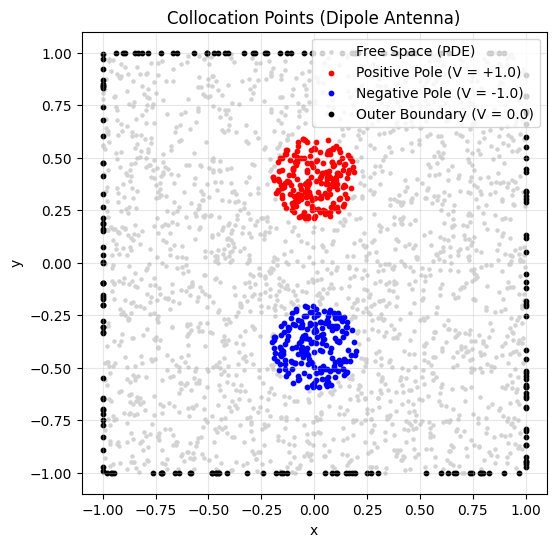

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# 재현성을 위한 난수 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. 도메인 및 배치 포인트 생성
# ==========================================

N_u = 600   # 경계 및 도체 내부 포인트 개수
N_f = 2000  # 자유 공간 내부 물리 법칙(PDE) 적용 포인트 개수

# 1-1. 양극 도체 포인트 생성 (V = +1.0)
r_p = np.sqrt(np.random.uniform(0, 0.2**2, (200, 1)))
theta_p = np.random.uniform(0, 2*np.pi, (200, 1))
x_pos = r_p * np.cos(theta_p)
y_pos = 0.4 + r_p * np.sin(theta_p)
V_pos = np.ones_like(x_pos) * 1.0
X_pos = np.hstack((x_pos, y_pos))

# 1-2. 음극 도체 포인트 생성 (V = -1.0)
r_n = np.sqrt(np.random.uniform(0, 0.2**2, (200, 1)))
theta_n = np.random.uniform(0, 2*np.pi, (200, 1))
x_neg = r_n * np.cos(theta_n)
y_neg = -0.4 + r_n * np.sin(theta_n)
V_neg = np.ones_like(x_neg) * -1.0
X_neg = np.hstack((x_neg, y_neg))

# 1-3. 외곽 경계 포인트 생성 (V = 0.0)
x_l = -np.ones((50, 1))
y_l = np.random.uniform(-1.0, 1.0, (50, 1))
x_r = np.ones((50, 1))
y_r = np.random.uniform(-1.0, 1.0, (50, 1))
y_b = -np.ones((50, 1))
x_b = np.random.uniform(-1.0, 1.0, (50, 1))
y_t = np.ones((50, 1))
x_t = np.random.uniform(-1.0, 1.0, (50, 1))

X_outer = np.vstack((np.hstack((x_l, y_l)), np.hstack((x_r, y_r)), np.hstack((x_b, y_b)), np.hstack((x_t, y_t))))
V_outer = np.zeros((X_outer.shape[0], 1))

# 경계 및 소스 데이터를 하나로 합칩니다
X_u = torch.FloatTensor(np.vstack((X_pos, X_neg, X_outer)))
V_u = torch.FloatTensor(np.vstack((V_pos, V_neg, V_outer)))

# 1-4. 자유 공간 내부 물리 검증점 생성 (도체 내부 제외)
x_f = np.random.uniform(-1.0, 1.0, (N_f * 3, 1))
y_f = np.random.uniform(-1.0, 1.0, (N_f * 3, 1))
X_f_np = np.hstack((x_f, y_f))

dist_pos = np.sqrt(X_f_np[:, 0]**2 + (X_f_np[:, 1] - 0.4)**2)
dist_neg = np.sqrt(X_f_np[:, 0]**2 + (X_f_np[:, 1] + 0.4)**2)
mask = (dist_pos > 0.2) & (dist_neg > 0.2)
X_f_np = X_f_np[mask][:N_f]

X_f = torch.FloatTensor(X_f_np)
X_f.requires_grad_(True)  # 편미분 계산용

# 도메인 가시화
plt.figure(figsize=(6, 6))
plt.scatter(X_f[:, 0].detach().numpy(), X_f[:, 1].detach().numpy(), c='lightgray', s=5, label='Free Space (PDE)')
plt.scatter(X_pos[:, 0], X_pos[:, 1], c='red', s=10, label='Positive Pole (V = +1.0)')
plt.scatter(X_neg[:, 0], X_neg[:, 1], c='blue', s=10, label='Negative Pole (V = -1.0)')
plt.scatter(X_outer[:, 0], X_outer[:, 1], c='black', s=10, label='Outer Boundary (V = 0.0)')
plt.title('Collocation Points (Dipole Antenna)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## 2. 하이퍼파라미터 및 신경망 구조 설정

다층 퍼셉트론(MLP)은 부드러운 전위의 미분을 표현할 수 있는 하이퍼볼릭 탄젠트(`Tanh`) 활성화 함수를 사용합니다.  
입력은 2차원 공간 좌표 $(x, y)$이고, 출력은 해당 위치의 전위 $V(x, y)$입니다.

In [2]:
learning_rate = 1e-3
epochs = 2000
hidden_layers = [64, 64, 64]

class TanhLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(TanhLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
    def forward(self, x):
        return torch.tanh(self.linear(x))

class DynamicTanhPINN(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super(DynamicTanhPINN, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(TanhLayer(input_size, hidden_layers[0]))
        for i in range(len(hidden_layers)-1):
            self.layers.append(TanhLayer(hidden_layers[i], hidden_layers[i+1]))
        self.output_layer = nn.Linear(hidden_layers[-1], output_size)
        
    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer(out)
        out = self.output_layer(out)
        return out, None

model = DynamicTanhPINN(input_size=2, hidden_layers=hidden_layers, output_size=1)
print(model)

DynamicTanhPINN(
  (layers): ModuleList(
    (0): TanhLayer(
      (linear): Linear(in_features=2, out_features=64, bias=True)
    )
    (1-2): 2 x TanhLayer(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


## 3. 물리 법칙 손실 함수 (PDE Loss) 정의

자유 공간 내부($X_f$)에서는 정전기학의 기본 물리 법칙인 **라플라스 방정식**이 성립해야 합니다.
$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

PyTorch의 자동 미분(`torch.autograd.grad`)을 이용해 2차 공간 미분값을 계산해 줍니다.

In [3]:
def calc_pde_loss(model_net, x_points):
    pred, _ = model_net(x_points)
    # 1. 1차 미분 (dV/dx, dV/dy)
    grad_V = torch.autograd.grad(pred, x_points, grad_outputs=torch.ones_like(pred), create_graph=True)[0]
    dV_dx = grad_V[:, 0:1]
    dV_dy = grad_V[:, 1:2]
    
    # 2. 2차 미분 (d2V/dx2, d2V/dy2)
    grad_dV_dx = torch.autograd.grad(dV_dx, x_points, grad_outputs=torch.ones_like(dV_dx), create_graph=True)[0]
    d2V_dx2 = grad_dV_dx[:, 0:1]
    
    grad_dV_dy = torch.autograd.grad(dV_dy, x_points, grad_outputs=torch.ones_like(dV_dy), create_graph=True)[0]
    d2V_dy2 = grad_dV_dy[:, 1:2]
    
    # 라플라시안 계산
    laplacian = d2V_dx2 + d2V_dy2
    loss_pde = torch.mean(laplacian**2)
    return loss_pde

## 4. PINN 반복 학습 수행

가장 기본적인 Adam 옵티마이저를 사용해 2000 에포크 동안 학습합니다.  
전체 손실 함수는 **경계 조건(BC) 손실과 물리 법칙(PDE) 손실의 선형 결합**으로 정의되며, 가중치는 표준적인 `100.0`을 사용합니다.
$$\text{Total Loss} = 100.0 \times \text{Loss_BC} + \text{Loss_PDE}$$

In [4]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []
start_time = time.time()

print("--- 다이폴 안테나 학습 시작 ---")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. 경계 조건 손실 계산 (Loss_BC)
    u_pred_bc, _ = model(X_u)
    Loss_BC = nn.MSELoss()(u_pred_bc, V_u)
    
    # 2. 물리 법칙 손실 계산 (Loss_PDE)
    Loss_PDE = calc_pde_loss(model, X_f)
    
    # 3. 토탈 Loss 계산 및 역전파
    loss = 100.0 * Loss_BC + Loss_PDE
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:4d}/{epochs}], Total Loss: {loss.item():.6e} (BC: {Loss_BC.item():.6e}, PDE: {Loss_PDE.item():.6e})")

print(f"학습 완료! (소요 시간: {time.time() - start_time:.2f}초)")

--- 다이폴 안테나 학습 시작 ---
Epoch [   1/2000], Total Loss: 7.478072e+01 (BC: 7.477197e-01, PDE: 8.742318e-03)
Epoch [ 200/2000], Total Loss: 1.298802e+01 (BC: 4.685611e-02, PDE: 8.302404e+00)
Epoch [ 400/2000], Total Loss: 2.205272e+00 (BC: 1.699365e-02, PDE: 5.059070e-01)
Epoch [ 600/2000], Total Loss: 1.985820e+00 (BC: 1.688437e-02, PDE: 2.973834e-01)
Epoch [ 800/2000], Total Loss: 1.802647e+00 (BC: 1.512798e-02, PDE: 2.898489e-01)
Epoch [1000/2000], Total Loss: 1.445972e+00 (BC: 1.167337e-02, PDE: 2.786354e-01)
Epoch [1200/2000], Total Loss: 1.069472e+00 (BC: 8.394569e-03, PDE: 2.300150e-01)
Epoch [1400/2000], Total Loss: 8.261424e-01 (BC: 6.272875e-03, PDE: 1.988548e-01)
Epoch [1600/2000], Total Loss: 6.164750e-01 (BC: 4.372211e-03, PDE: 1.792539e-01)
Epoch [1800/2000], Total Loss: 4.609769e-01 (BC: 3.405273e-03, PDE: 1.204496e-01)
Epoch [2000/2000], Total Loss: 4.040100e-01 (BC: 3.035378e-03, PDE: 1.004722e-01)
학습 완료! (소요 시간: 51.43초)


## 5. 전위 및 전기장 시각화

학습된 신경망으로부터 전위 분포 $V(x, y)$와 이로부터 전기장 $\vec{E} = -\nabla V$를 유도하여 시각화합니다.

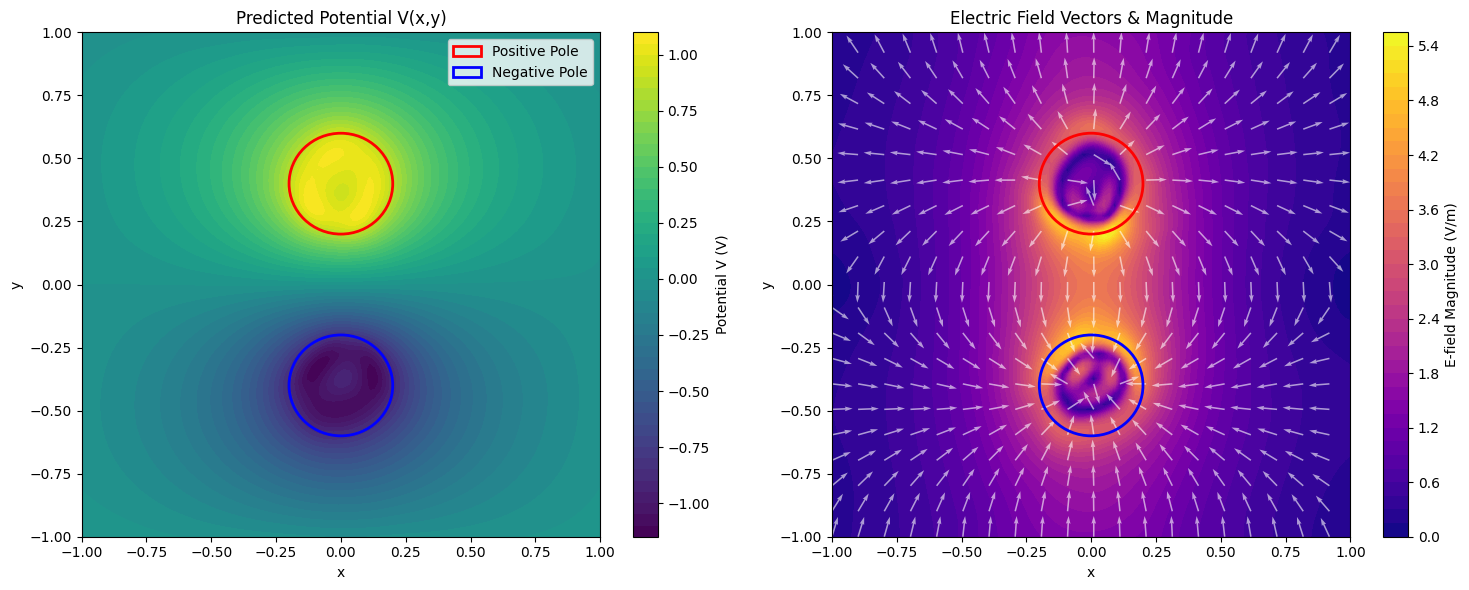

In [5]:
# 5-1. 그리드 데이터 생성
x_grid = np.linspace(-1.0, 1.0, 100)
y_grid = np.linspace(-1.0, 1.0, 100)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
grid_tensor = torch.FloatTensor(np.c_[X_mesh.ravel(), Y_mesh.ravel()])
grid_tensor.requires_grad = True

# 5-2. 전위 및 전기장 계산
V_pred, _ = model(grid_tensor)
grad_V = torch.autograd.grad(V_pred, grid_tensor, grad_outputs=torch.ones_like(V_pred), create_graph=False)[0]

Ex = -grad_V[:, 0:1].detach().numpy().reshape(X_mesh.shape)
Ey = -grad_V[:, 1:2].detach().numpy().reshape(X_mesh.shape)
E_magnitude = np.sqrt(Ex**2 + Ey**2)
V_pred_np = V_pred.detach().numpy().reshape(X_mesh.shape)

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. 전위 분포 히트맵
contour_v = ax1.contourf(X_mesh, Y_mesh, V_pred_np, levels=50, cmap='viridis')
fig.colorbar(contour_v, ax=ax1, label='Potential V (V)')
# 도체 그리기
circle_p = plt.Circle((0, 0.4), 0.2, color='red', fill=False, linewidth=2, label='Positive Pole')
circle_n = plt.Circle((0, -0.4), 0.2, color='blue', fill=False, linewidth=2, label='Negative Pole')
ax1.add_patch(circle_p)
ax1.add_patch(circle_n)
ax1.set_title("Predicted Potential V(x,y)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(loc='upper right')

# 2. 전기장 벡터 및 세기 분포
contour_e = ax2.contourf(X_mesh, Y_mesh, E_magnitude, levels=50, cmap='plasma')
fig.colorbar(contour_e, ax=ax2, label='E-field Magnitude (V/m)')
sub = 5
ax2.quiver(X_mesh[::sub, ::sub], Y_mesh[::sub, ::sub], 
           Ex[::sub, ::sub] / (E_magnitude[::sub, ::sub] + 1e-8), 
           Ey[::sub, ::sub] / (E_magnitude[::sub, ::sub] + 1e-8), 
           color='white', alpha=0.6, scale=25)
circle_p_e = plt.Circle((0, 0.4), 0.2, color='red', fill=False, linewidth=2)
circle_n_e = plt.Circle((0, -0.4), 0.2, color='blue', fill=False, linewidth=2)
ax2.add_patch(circle_p_e)
ax2.add_patch(circle_n_e)
ax2.set_title("Electric Field Vectors & Magnitude")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()